In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE

DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]
SEED = 42

In [ ]:
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
distance_matrix = np.load('../duomenys/dist_mat.npy')

In [ ]:
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [ ]:
from sklearn.model_selection import train_test_split

original_flat = original_data.reshape((-1, original_data.shape[1]*original_data.shape[2]))
X_train, X_test, y_train, y_test, emb_train, emb_test = train_test_split(
    original_flat, labels_encoded, embedding, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [ ]:
import pandas as pd

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
def run_random_forest(X_train, X_test, y_train, y_test, label_names, **params):

    rf = RandomForestClassifier(**params)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    for param, v in params.items():
        print(f"{param} : {v}")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm)
    print(cm_df.to_string())

    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)

    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n

    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in range(5)]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")

    return rf

In [ ]:
rf_orig = run_random_forest(X_train, X_test, y_train, y_test, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  36   2   0   2   5
1   6  35   0   1   3
2   2   0  42   0   1
3   0   1   2  40   2
4   5   2   0   0  38

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7347  0.8000  0.7660
Fishing       0.8750  0.7778  0.8235
Passenger     0.9545  0.9333  0.9438
Pilot         0.9302  0.8889  0.9091
Tanker        0.7755  0.8444  0.8085

Accuracy      : 0.8489
Macro precision : 0.8540
Macro recall    : 0.8489
Macro F1        : 0.8502


In [ ]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    embedding, labels_encoded, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [ ]:
rf_proj = run_random_forest(X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  26   5   3   1  10
1   5  34   3   0   3
2   2   0  37   3   3
3   0   0   1  41   3
4   7   3   4   0  31

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6500  0.5778  0.6118
Fishing       0.8095  0.7556  0.7816
Passenger     0.7708  0.8222  0.7957
Pilot         0.9111  0.9111  0.9111
Tanker        0.6200  0.6889  0.6526

Accuracy      : 0.7511
Macro precision : 0.7523
Macro recall    : 0.7511
Macro F1        : 0.7506


In [ ]:
import matplotlib.colors as mcolors

In [ ]:
def plot_decision_boundary(
    clf, 
    X_test_sc,
    y_test,
    label_names,
    title,
    ax,
    unique_classes,
    step=0.3
):

    x_min = X_test_sc[:,0].min() - 1
    x_max = X_test_sc[:,0].max() + 1
    y_min = X_test_sc[:,1].min() - 1
    y_max = X_test_sc[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_test == cls
        ax.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




In [ ]:
import matplotlib.pyplot as plt

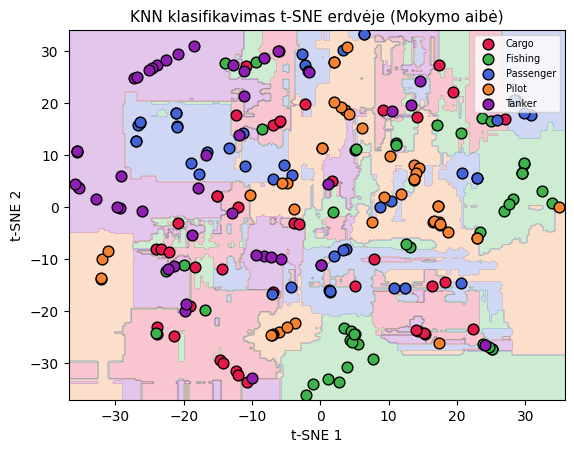

In [ ]:
fig, ax = plt.subplots()

plot_decision_boundary(
    rf_proj, X_test_tsne, y_test_tsne, label_names, unique_classes=all_classes,
    title="RF klasifikavimas t-SNE erdvėje (Mokymo aibė)",
    ax=ax
)

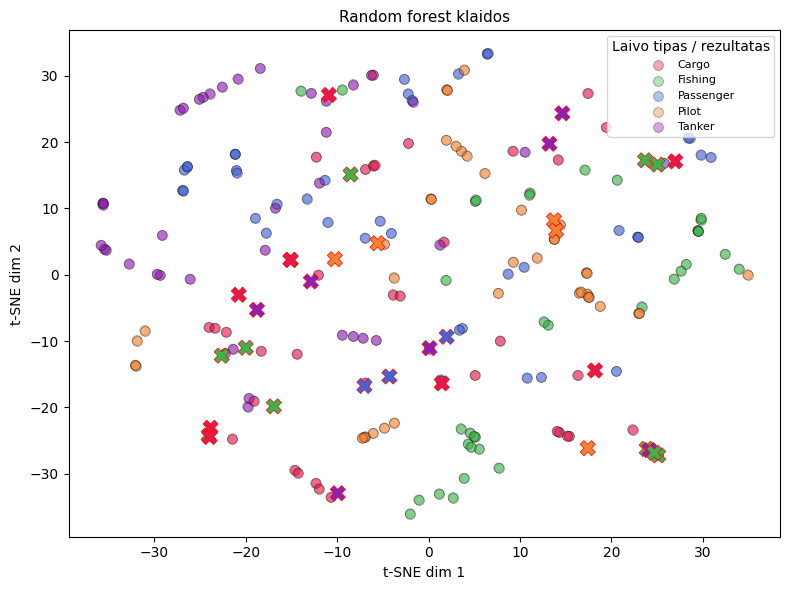

In [ ]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_orig.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Random forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

param_grid = {
    'n_estimators': [20, 75, 100, 200],
    'max_depth':    [None, 8, 32, 64],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV acc:  {grid_search.best_score_:.4f}")

# Full results as a sorted DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# ── Best model ready to use ───────────────────────────────────────────────────
rf_best = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params:  {'max_depth': None, 'n_estimators': 75}
Best CV acc:  0.8095
 param_n_estimators param_max_depth  mean_train_score  mean_test_score  std_test_score  rank_test_score
                 75            None          1.000000         0.809524        0.045873                1
                100            None          1.000000         0.809524        0.043851                1
                100              32          1.000000         0.809524        0.043851                1
                 75              32          1.000000         0.809524        0.045873                1
                 75              64          1.000000         0.809524        0.045873                1
                100              64          1.000000         0.809524        0.043851                1
                 20               8          0.924286         0.803810        0.050968                7
                 20            N

> Geriausias hiperparametrų rinkinys - 75 estimatoriai ir neribotas medžio gylis

In [ ]:
rf_optim = run_random_forest(X_train, X_test, y_train, y_test, label_names,
                            **grid_search.best_params_)


max_depth : None
n_estimators : 75
Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  38   1   0   1   5
1   6  35   0   1   3
2   2   0  43   0   0
3   0   1   2  40   2
4   5   3   0   0  37

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.7451  0.8444  0.7917
Fishing       0.8750  0.7778  0.8235
Passenger     0.9556  0.9556  0.9556
Pilot         0.9524  0.8889  0.9195
Tanker        0.7872  0.8222  0.8043

Accuracy      : 0.8578
Macro precision : 0.8631
Macro recall    : 0.8578
Macro F1        : 0.8589


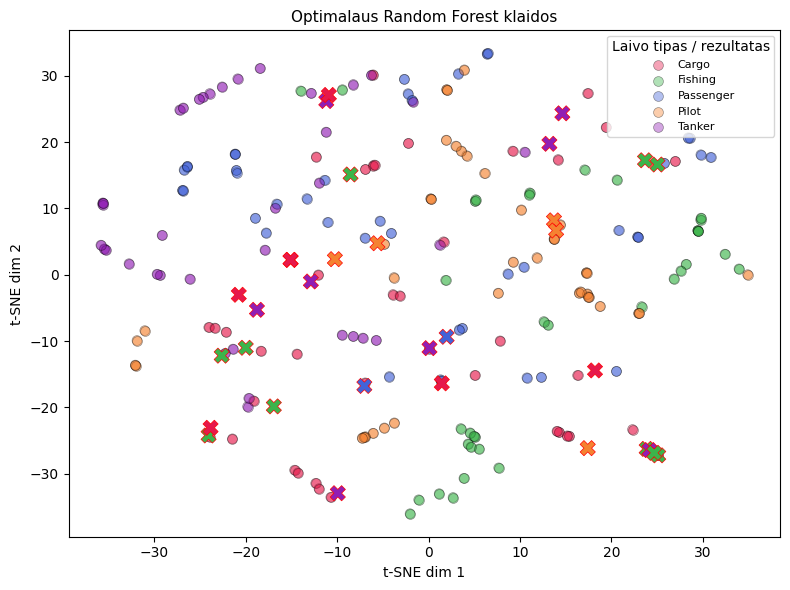

In [ ]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Optimalaus Random Forest klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/rf_errors_orig.svg', format='svg')
plt.show()


In [ ]:
unique_cls = np.unique(labels_encoded)
y_pred = rf_optim.predict(X_test)
correct = y_pred == y_test 

class_data = {
    'correct': {},
    'incorrect': {}
}

for cls in unique_cls:
    class_data['correct'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [correct & (y_test == cls)], axis=0
    ).mean(axis=0)

    class_data['incorrect'][cls] = np.mean(X_test\
        .reshape((-1, 25, 10))\
        [~correct & (y_test == cls)], axis=0
    ).mean(axis=0)

df = pd.DataFrame(
    {(status, label): values
     for status, classes in class_data.items()
     for label, values in classes.items()}
)

df['correct', 'feature_number'] = np.arange(df.shape[0])
df['incorrect', 'feature_number'] = np.arange(df.shape[0])

df_correct = df['correct'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_correct['status'] = 'correct'

df_incorrect = df['incorrect'].melt(id_vars='feature_number', var_name='class', value_name='mean_value')
df_incorrect['status'] = 'incorrect'

comparison_df = pd.concat([df_correct, df_incorrect], ignore_index=True)

In [ ]:
pivot_df = comparison_df.pivot_table(
    index=['feature_number', 'class'],
    columns='status',
    values='mean_value'
).reset_index()

pivot_df.columns.name = None

pivot_df = pivot_df.rename(columns={
    'correct': 'mean_correct',
    'incorrect': 'mean_incorrect'
})

pivot_df['difference'] = pivot_df['mean_correct'] - pivot_df['mean_incorrect']
pivot_df['abs_difference'] = pivot_df['difference'].abs()

pivot_df = pivot_df.sort_values('abs_difference', ascending=False)

print(pivot_df.to_string(index=False))

 feature_number  class  mean_correct  mean_incorrect    difference  abs_difference
              7      2      0.468684        0.876297 -4.076131e-01    4.076131e-01
              1      4      0.681123        0.327365  3.537580e-01    3.537580e-01
              3      3      0.104838        0.445897 -3.410586e-01    3.410586e-01
              4      4      0.934866        0.607162  3.277044e-01    3.277044e-01
              3      2      0.455554        0.164557  2.909976e-01    2.909976e-01
              6      4      0.882520        0.595632  2.868880e-01    2.868880e-01
              3      1      0.118738        0.369612 -2.508744e-01    2.508744e-01
              5      2      0.487519        0.724382 -2.368631e-01    2.368631e-01
              0      0      0.706619        0.488798  2.178208e-01    2.178208e-01
              7      4      0.337671        0.532237 -1.945662e-01    1.945662e-01
              1      2      0.362469        0.176401  1.860679e-01    1.860679e-01
    